In [61]:
print(2+5)

7


In [62]:
import pandas as p

df = p.read_csv("salaries.csv")

In [63]:
df

,years_of_experience,salary
0,5,3150
1,9,3787
2,4,2991
3,10,4551
4,8,3540
...,...,...
95,4,2884
96,4,2810
97,2,2488
98,7,3661


In [64]:
df.head(5)

,years_of_experience,salary
0,5,3150
1,9,3787
2,4,2991
3,10,4551
4,8,3540


In [65]:
x= df.iloc[1,1]
x

np.int64(3787)

We need to split our dataframe into x and y.

In [66]:
x=df.iloc[0:5,0:-1].values
y = df.iloc[:,-1].values   # get all rows with only the last column
x
y

array([3150, 3787, 2991, 4551, 3540, 3881, 2559, 3269, 2767, 2978, 2781,
       2632, 2237, 3281, 3940, 3467, 4708, 2328, 4109, 3286, 3952, 3417,
       3638, 3289, 2698, 3357, 2669, 3253, 2526, 2922, 3638, 3906, 2793,
       3099, 3384, 3819, 4227, 2844, 2753, 3561, 2560, 3256, 2801, 3409,
       4553, 2669, 3840, 2841, 3049, 3751, 2748, 2762, 2501, 2389, 3599,
       3751, 2825, 3442, 3432, 3335, 3569, 2749, 2669, 4033, 3845, 3632,
       3573, 3435, 3665, 3054, 3084, 3588, 3603, 3070, 3417, 3575, 3813,
       2644, 3060, 2497, 2479, 2923, 2566, 3483, 2475, 4135, 3661, 3215,
       3257, 2781, 2827, 3134, 3397, 2672, 3845, 2884, 2810, 2488, 3661,
       2496])

In [67]:
x[1:5]

array([[ 9],
       [ 4],
       [10],
       [ 8]])

In [68]:
import matplotlib.pyplot as plt

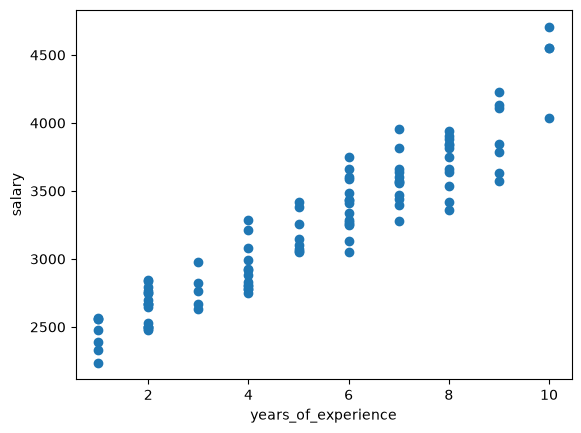

In [70]:
# ensure x matches y (100 rows) and use pyplot's scatter
x = df.iloc[:, 0].values
plt.scatter(x, y)
plt.xlabel('years_of_experience')
plt.ylabel('salary')
plt.show()

scikit do train

In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [80]:
x_train.shape

(80,)

In [74]:
x_test.shape

(20,)

linear regression

In [83]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [90]:
LinearRegression()
LinearRegression()
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[192.66]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2238
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[23.71]


prediction

In [93]:
y_pred = model.predict(x_test)
y_pred

array([2816.37966916, 3779.68276414, 3009.04028815, 3779.68276414,
       3587.02214514, 2623.71905016, 4165.00400213, 3201.70090715,
       3587.02214514, 3009.04028815, 2431.05843116, 3587.02214514,
       3201.70090715, 3587.02214514, 3394.36152615, 3587.02214514,
       3779.68276414, 2623.71905016, 3201.70090715, 2816.37966916])

predicting salaries for those not in training set

In [94]:
salary = model.predict([[11], [13]])
salary

array([4357.66462113, 4742.98585912])

In [ ]:
salary = model.predict([[7], [9]]) # already present in training, check, but multiple same years
salary

array([3587.02214514, 3972.34338314])

compare with testing set which we separated from training

In [96]:
y_test

array([2669, 3661, 2991, 3751, 3575, 2672, 4708, 3070, 3599, 2884, 2389,
       3397, 3060, 3281, 3269, 3638, 3638, 2698, 3099, 2767])

In [ ]:
error = y_pred - y_test
error

array([ 147.37966916,  118.68276414,   18.04028815,   28.68276414,
         12.02214514,  -48.28094984, -542.99599787,  131.70090715,
        -11.97785486,  125.04028815,   42.05843116,  190.02214514,
        141.70090715,  306.02214514,  125.36152615,  -50.97785486,
        141.68276414,  -74.28094984,  102.70090715,   49.37966916])

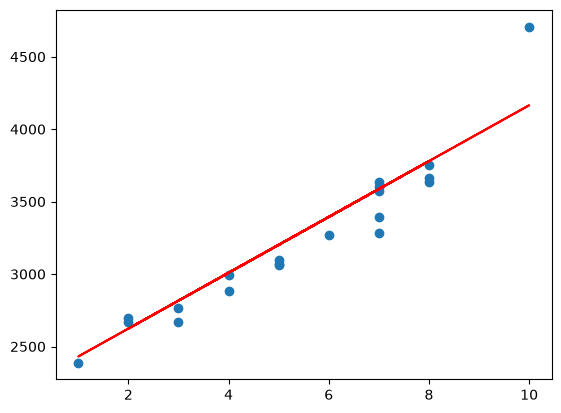

In [99]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color="red") 

FINAL STEP - accuracy of the model

In [103]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)                           

print(f"R2 Score: {r2} ({r2:.2%})")

R2 Score: 0.8921287198195745 (89.21%)
